In [46]:
import lancedb
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from helpers.embedding_experiment import (
    build_cli_command,
    get_model_info,
    list_models,
    load_config,
    print_table_sizes,
    run_experiment,
    setup_experiment,
)

In [47]:
list_models()

Family          Script                                        Description
----------------------------------------------------------------------------------------------------
dinov3          v4_dino_embeddings_lancedb.py                 DINOv2/v3 ViT models with patch embeddings and attention maps
openclip        v1_openclip_embeddings_lancedb.py             OpenCLIP ViT models with patch embeddings and attention maps (img_emb_dim=768, patch_emb_dim=1024)


In [ ]:
PROJECT_ROOT = Path("/Users/ncheruku/Documents/Work/github/bams-ai-data-exploration/.claude/worktrees/vigilant-nobel")

SOURCE_URI = PROJECT_ROOT / "data" / "lancedb" / "shared_source"
IMG_RAW_TBL_NAME = "era5_sample_images"
DB_URI = PROJECT_ROOT / "data" / "lancedb" / "experiments" / "era5"
AUTHOR = "Cherukuru. N. W"

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [ ]:
# Model-specific config — change this for a different model family
PROJECT_NAME = "openclip"
model_info = get_model_info(PROJECT_NAME)

MODEL = model_info["default_model"]
SCRIPT = model_info["script_path"]
BATCH = model_info["default_batch"]
WORKERS = model_info["default_workers"]
SCAN_BATCH = model_info.get("default_scan_batch", 1000)

print(f"Family: {PROJECT_NAME}")
print(f"Script: {model_info['script']}")
print(f"Model:  {MODEL}")

In [ ]:
experiment = setup_experiment(
    PROJECT_NAME, AUTHOR, SOURCE_URI, IMG_RAW_TBL_NAME,
    DB_URI, project_root=PROJECT_ROOT,
)

In [ ]:
# Case 1: Run inline (interactive notebook workflow)
run_experiment(
    SCRIPT, SOURCE_URI, IMG_RAW_TBL_NAME,
    DB_URI, experiment["config_name"], PROJECT_NAME,
    MODEL, batch=BATCH, scan_batch=SCAN_BATCH, workers=WORKERS,
)

In [ ]:
# Case 2: Build CLI command for PBS / external job submission
cmd = build_cli_command(
    SCRIPT, SOURCE_URI, IMG_RAW_TBL_NAME,
    DB_URI, experiment["config_name"], PROJECT_NAME,
    MODEL, batch=BATCH, scan_batch=SCAN_BATCH, workers=WORKERS,
)
print(cmd)

In [ ]:
# Inspect config after run completes (works for both Case 1 and Case 2)
config = load_config(DB_URI, experiment["config_name"])
config

In [18]:
print_table_sizes(
    DB_URI,
    experiment["config_name"],
    experiment["img_emb_name"],
    experiment["patch_emb_name"],
)

Table                                               Size
---------------------------------------------------------
openclip_config                                692.89 KB
openclip_image_embeddings                        4.35 MB
openclip_patch_embeddings                        1.10 GB
---------------------------------------------------------
TOTAL                                            1.11 GB


In [ ]:
db = lancedb.connect(str(DB_URI))
patch_tbl = db.open_table(experiment["patch_emb_name"])

In [20]:
img_tbl = db.open_table(experiment["img_emb_name"])

In [ ]:
def preview_image_embedding(tbl, idx: int = 0) -> None:
    """Preview a single row from the image embeddings table by index.

    Prints a column summary and renders two plots:
      - Left:  histogram of the embedding vector values
      - Right: attention map reshaped to its spatial grid (e.g. 16×16)

    Parameters
    ----------
    tbl : LanceDB Table
        The image embeddings table (must have columns: image_id, embedding, attention_map).
    idx : int
        Row index to inspect.
    """
    row = tbl.to_lance().take([idx]).to_pydict()

    image_id = row["image_id"][0]
    emb = np.array(row["embedding"][0], dtype=np.float32)
    attn = np.array(row["attention_map"][0], dtype=np.float32)

    # Auto-detect spatial grid from attention map length
    spatial = int(round(len(attn) ** 0.5))
    attn_2d = attn.reshape(spatial, spatial)

    # ── Column summary ──────────────────────────────────────────────────
    print(f"idx         : {idx}")
    print(f"image_id    : {image_id}")
    print(f"embedding   : dim={len(emb)}, norm={np.linalg.norm(emb):.6f}, "
          f"min={emb.min():.4f}, max={emb.max():.4f}, mean={emb.mean():.4f}")
    print(f"attention   : patches={len(attn)} ({spatial}×{spatial}), "
          f"min={attn.min():.4f}, max={attn.max():.4f}, sum={attn.sum():.4f}")

    # ── Plots ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f"idx={idx}  |  {image_id}", fontsize=10)

    # Embedding histogram
    axes[0].hist(emb, bins=64, color="steelblue", edgecolor="none")
    axes[0].axvline(emb.mean(), color="tomato", linestyle="--",
                    label=f"mean = {emb.mean():.3f}")
    axes[0].set_title(f"Embedding  (dim={len(emb)}, ‖v‖={np.linalg.norm(emb):.4f})")
    axes[0].set_xlabel("value")
    axes[0].set_ylabel("count")
    axes[0].legend(fontsize=8)

    # Attention map heatmap
    im = axes[1].imshow(attn_2d, cmap="inferno", interpolation="nearest")
    axes[1].set_title(f"Attention map  ({spatial}×{spatial})")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

idx         : 789
image_id    : 5a4c301b8429d7d3f1cdfded6cb49d25
embedding   : dim=768, norm=1.000000, min=-0.6382, max=0.1272, mean=-0.0019
attention   : patches=256 (16×16), min=0.0002, max=0.0512, sum=0.7821


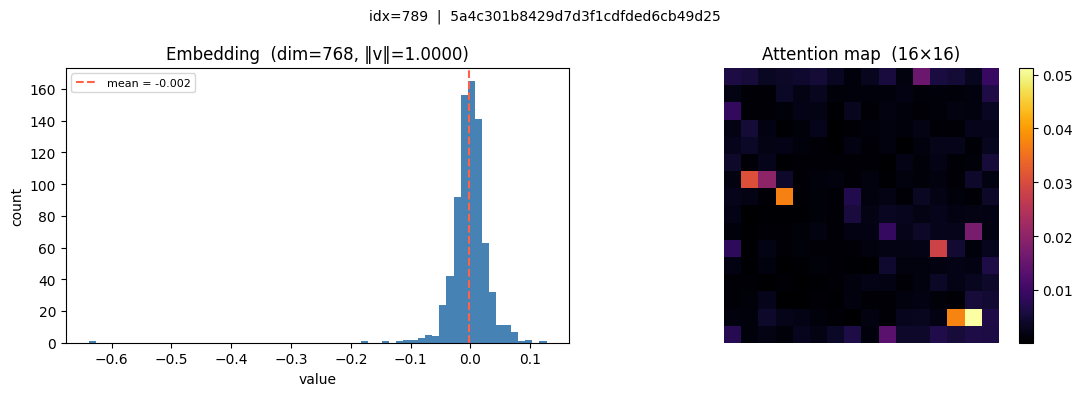

In [23]:
preview_image_embedding(img_tbl, idx=789)

In [ ]:
patch_tbl.schema

In [ ]:
row = patch_tbl.search().limit(1).to_pandas().iloc[0]
row["image_id"]

In [ ]:
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")

In [ ]:
patch_tbl.create_index(metric="cosine", index_type="IVF_PQ", num_partitions=128, num_sub_vectors=96, accelerator="cuda", vector_column_name="embedding")